We are building a Sequential Workflow using LangGraph and Google Gemini. Our objective is to create a Sequential System for AI Helth consultation


In [1]:
!pip install langgraph langchain langchain-google-genai google-generativeai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 855.0 kB/s eta 0:00:00


In [2]:
#Installing the required dependencies
from langgraph.graph import StateGraph, START, END #START and END are dummy nodes in LangGraph
from typing import TypedDict #this is a special type of Dict where we specify the datatype also
from langchain_google_genai import ChatGoogleGenerativeAI #for getting a response from the LLM
from langchain_core.tools import tool
from IPython.display import Image #visualize the workflow created using LangGraph

In [ ]:
#Configuring the Gemini API
import os
os.environ["GOOGLE_API_KEY"]=""

In [4]:
#Initializing the Gemini LLM
llm=ChatGoogleGenerativeAI(
    model='gemini-2.5-flash'
)

In [ ]:
from typing import TypedDict


class HealthcareState(TypedDict):

    # Inputs from Patient
    fever: float
    oxygen_level: int
    heart_rate: int
    symptom_duration: int

    patient_age: int
    existing_conditions: str

    # Step 1 Output (Health Analysis Tool)
    severity_level: str

    # Step 2 Output (Gemini Prioritization)
    consultation_priority: str

    # Step 3 Output (Final Assignment)
    final_assignment: str

With respect to Tools, we should always have the following 3 things defined in a Tool

- Name of the Tool
- Description of the Tool
- Input schema of the Tool

In [24]:
# Creating a Tool for Patient Health Analysis

from langchain.tools import tool

@tool
def patient_health_analysis_tool(
    fever: float,
    oxygen_level: int,
    heart_rate: int,
    symptom_duration: int
) -> str:

    """
    This tool analyzes patient vitals
    and determines severity level.
    """

    # Critical Conditions
    if oxygen_level < 85 or heart_rate > 130:
        return "CRITICAL"

    # Moderate Conditions
    if fever > 102 or symptom_duration > 7:
        return "MODERATE"

    # Otherwise Stable
    return "STABLE"


In [25]:
# Creating First Node for Patient Health Analysis

def patient_health_analysis_node(state: HealthcareState) -> HealthcareState:

    result = patient_health_analysis_tool.invoke({

        "fever": state['fever'],
        "oxygen_level": state['oxygen_level'],
        "heart_rate": state['heart_rate'],
        "symptom_duration": state['symptom_duration']

    })

    # Store tool output in workflow state
    state['severity_level'] = result

    return state

In [26]:
# Creating a Node for Gemini Medical Prioritization

def medical_prioritization_node(state: HealthcareState) -> HealthcareState:

    prompt = f"""
    Analyze this patient case.

    Severity Level: {state['severity_level']}
    Patient Age: {state['patient_age']}
    Existing Conditions: {state['existing_conditions']}

    Classify the consultation priority strictly as one of:

    EMERGENCY
    PRIORITY_CONSULTATION
    REGULAR_CONSULTATION
    """

    response = llm.invoke(prompt)

    # Store Gemini output in workflow state
    state['consultation_priority'] = response.content.strip()

    return state

In [27]:
# Creating Final Consultation Assignment Node

def consultation_assignment_node(state: HealthcareState) -> HealthcareState:

    # Final assignment based on consultation priority
    if state['consultation_priority'] == "EMERGENCY":
        state['final_assignment'] = "ICU/ER"

    elif state['consultation_priority'] == "PRIORITY_CONSULTATION":
        state['final_assignment'] = "SPECIALIST_DOCTOR"

    elif state['consultation_priority'] == "REGULAR_CONSULTATION":
        state['final_assignment'] = "GENERAL_PHYSICIAN"

    else:
        state['final_assignment'] = "UNKNOWN_ASSIGNMENT"

    return state

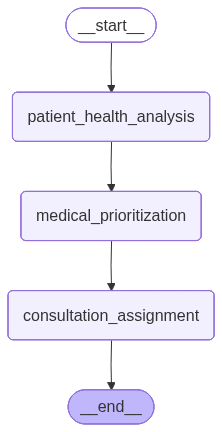

In [28]:
# Compiling the Healthcare Workflow

from langgraph.graph import StateGraph, END

graph = StateGraph(HealthcareState)

# Adding Nodes
graph.add_node("patient_health_analysis", patient_health_analysis_node)

graph.add_node("medical_prioritization",
               medical_prioritization_node)

graph.add_node("consultation_assignment",
               consultation_assignment_node)

# Entry Point
graph.set_entry_point("patient_health_analysis")

# Connecting Nodes
graph.add_edge("patient_health_analysis",
               "medical_prioritization")

graph.add_edge("medical_prioritization",
               "consultation_assignment")

graph.add_edge("consultation_assignment", END)

# Compile Workflow
workflow = graph.compile()
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))


In [29]:
initial_state:HealthcareState={

     "fever": 103,
    "oxygen_level": 82,
    "heart_rate": 125,
    "symptom_duration": 5,

    "patient_age": 70,
    "existing_conditions": "Diabetes"

}

print(workflow.invoke(initial_state))

{'fever': 103, 'oxygen_level': 82, 'heart_rate': 125, 'symptom_duration': 5, 'patient_age': 70, 'existing_conditions': 'Diabetes', 'severity_level': 'CRITICAL', 'consultation_priority': 'EMERGENCY', 'final_assignment': 'ICU/ER'}
